Class labels [1 2 3]
standardized: [-1.46385011 -0.87831007 -0.29277002  0.29277002  0.87831007  1.46385011]
normalized: [0.  0.2 0.4 0.6 0.8 1. ]
Training accuracy: 1.0
Test accuracy: 1.0


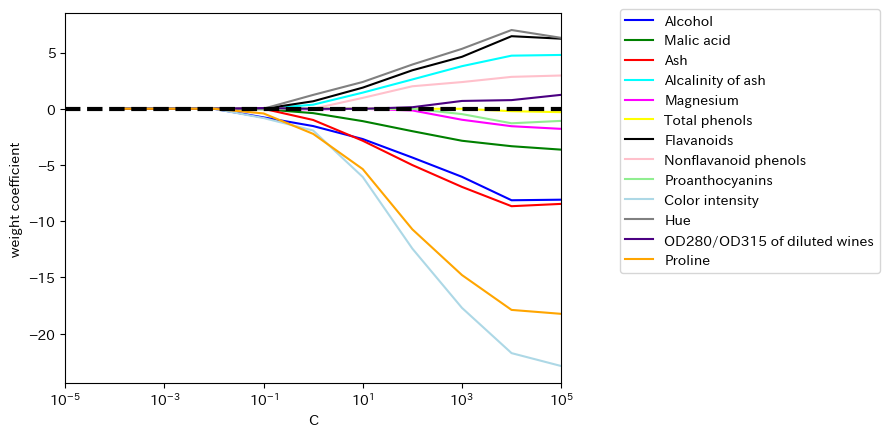

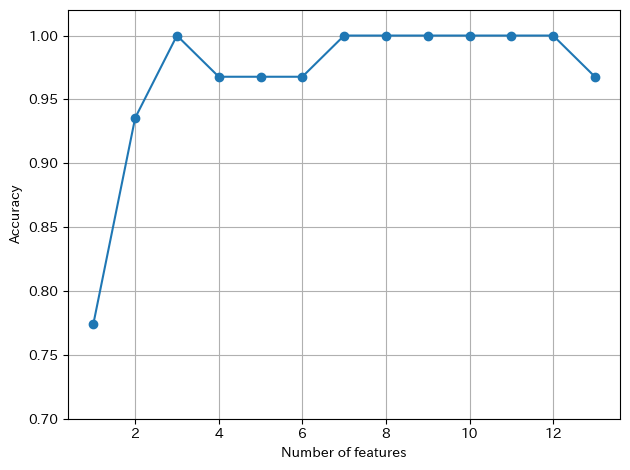

Index(['Alcohol', 'Malic acid', 'OD280/OD315 of diluted wines'], dtype='object')
Training accuracy: 0.967741935483871
Test accuracy: 0.9629629629629629
Training accuracy: 0.9516129032258065
Test accuracy: 0.9259259259259259
 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
 6) Hue                            0.058739
 7) Total phenols                  0.050872
 8) Magnesium                      0.031357
 9) Malic acid                     0.025648
10) Proanthocyanins                0.025570
11) Alcalinity of ash              0.022366
12) Nonflavanoid phenols           0.013354
13) Ash                            0.013279


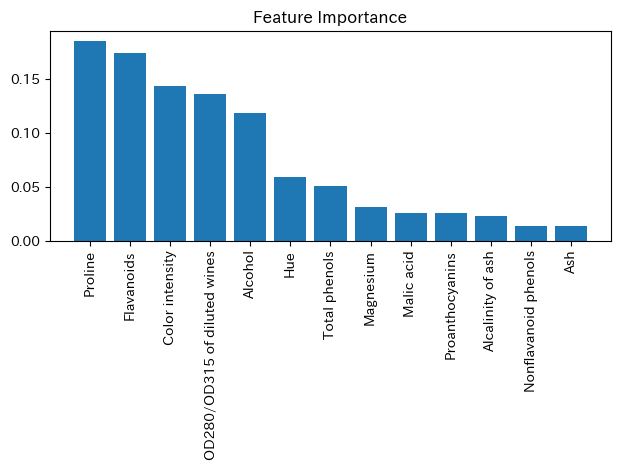

Number of features that meet this threshold criterion: 5
 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529


In [1]:
from ch04 import SBS
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import numpy as np

import pandas as pd

cols = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

df_wine = pd.read_csv("wine.data",names=cols,header=None)


In [2]:
from sklearn.model_selection import train_test_split

y, x = df_wine["Class label"], df_wine.iloc[:,1:]

x_train, x_test, y_train, y_test = train_test_split(x.values,y.values, test_size=0.3, random_state=0, stratify=y)

from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_train_std = std.fit_transform(x_train)
x_test_std = std.transform(x_test)

In [3]:
# selecting features
knn = KNeighborsClassifier(n_neighbors=5)

sbs = SBS(knn, k_features=4)
sbs.fit(x_train_std, y_train)

# plotting performance of feature subsets
k_feat = [len(k) for k in sbs.subsets_]



ランダムフォレストによる特徴量選択

In [19]:
from sklearn.ensemble import RandomForestClassifier
n_feat = 5
feat_labels = df_wine.columns[1:]
forest2 = RandomForestClassifier(n_estimators=500, random_state=1)
forest2.fit(x_train_std, y_train)
importances = forest2.feature_importances_
indices5 = np.argsort(importances)[::-1][:n_feat]
cumsum = 0
for i, idx in enumerate(indices5):
  cumsum += importances[idx]
  print("%d) %2d: %-*s %3f, %3f"%(i+1,idx + 1, 30, feat_labels[idx], importances[idx], cumsum))
x_train_forest = x_train_std[:,indices5]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_forest, y_train)
print("Training Acc.: %.3f"%(knn.score(x_train_forest, y_train)))
x_test_forest= x_test_std[:,indices5]
knn.fit(x_test_forest, y_test)
print("Test Acc.: %.3f"%(knn.score(x_test_forest, y_test)))

1) 13: Proline                        0.185453, 0.185453
2)  7: Flavanoids                     0.174751, 0.360204
3) 10: Color intensity                0.143920, 0.504123
4) 12: OD280/OD315 of diluted wines   0.136162, 0.640285
5)  1: Alcohol                        0.118529, 0.758815
Training Acc.: 0.968
Test Acc.: 1.000


In [25]:
from sklearn.feature_selection import SelectFromModel


sfm = SelectFromModel(
  estimator = forest2,#分類機のインスタンス
  threshold = 0.00001,
  max_features=5,
  prefit = True
  )

x_train_selected = sfm.transform(x_train_std)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_selected, y_train)
print("Training Acc.: %.3f"%(knn.score(x_train_selected, y_train)))
x_test_selected = sfm.transform(x_test_std)
knn.fit(x_test_selected, y_test)
print("Test Acc.: %.3f"%(knn.score(x_test_selected, y_test)))


Training Acc.: 0.968
Test Acc.: 1.000


In [23]:
x_train_selected.shape

(124, 13)

In [22]:
x_train_forest

array([[-0.62946362, -1.24000033, -0.29218864, -0.82164144,  0.71225893],
       [ 1.47568796,  0.66299475,  0.13152077,  0.54931269,  0.88229214],
       [ 1.62934866,  1.16326665,  0.25863359,  0.1308109 ,  0.84585645],
       [ 1.045438  ,  0.45700044, -0.37693052,  0.36170844,  0.57866141],
       [-0.18384759, -1.37732987,  0.85182676, -1.49990297, -0.52655446],
       [-1.13654393,  0.22157837, -0.92775274,  0.82350352, -1.15810638],
       [-1.36088855, -0.02365296, -1.01249463,  0.57817489, -0.98807317],
       [-0.32214222, -1.45580389,  0.15270624, -1.60092064, -0.63586152],
       [-0.79849039, -0.59258963, -0.86419633, -0.80721035, -0.41724739],
       [-1.04434751, -0.41602308, -1.28366864, -0.25882869, -1.47388234],
       [-0.86917431, -0.21983802, -0.57183684,  0.23182858,  0.55437095],
       [ 1.045438  ,  1.4673535 ,  0.14423205,  1.35745408,  1.02803489],
       [-1.17649571, -0.79858394, -0.71589804, -0.72062377, -0.32008556],
       [-0.87532074, -1.52446866,  2.0